# Data Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('cleaned_data/cleaned_data.csv')
print(data.head())

  country  year  wdi_internet  wdi_gdpcapcon2015  undp_hdi  vdem_libdem  \
0  Angola  2013       13.0000        3716.297187     0.567        0.123   
1  Angola  2014       21.3623        3746.816200     0.577        0.123   
2  Angola  2015       22.0000        3641.728939     0.603        0.123   
3  Angola  2016       23.2000        3454.033172     0.609        0.124   
4  Angola  2017       26.0000        3328.898212     0.610        0.142   

   ti_cpi  freedom_score  freedom_status  
0    23.0             66               2  
1    19.0             62               2  
2    15.0             61               2  
3    18.0             60               2  
4    19.0             60               2  


<Axes: >

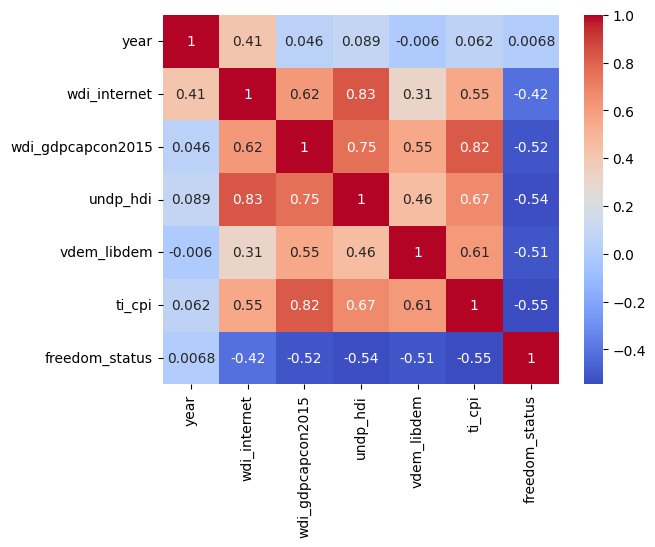

In [10]:
corr = data.drop(columns=['country', 'freedom_score']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='wdi_internet', ylabel='freedom_score'>

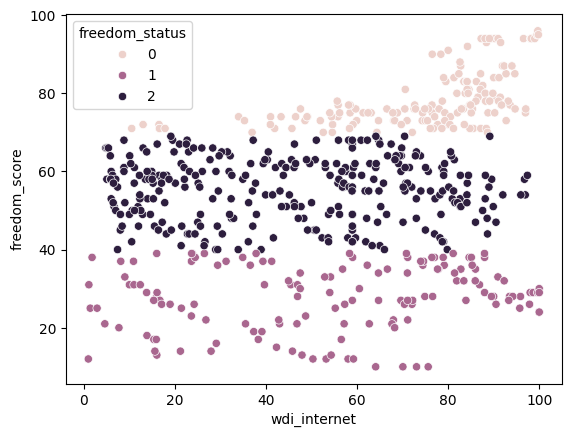

In [14]:
sns.scatterplot(data=data, x='wdi_internet', y='freedom_score', hue='freedom_status')

<Axes: xlabel='wdi_internet', ylabel='freedom_score'>

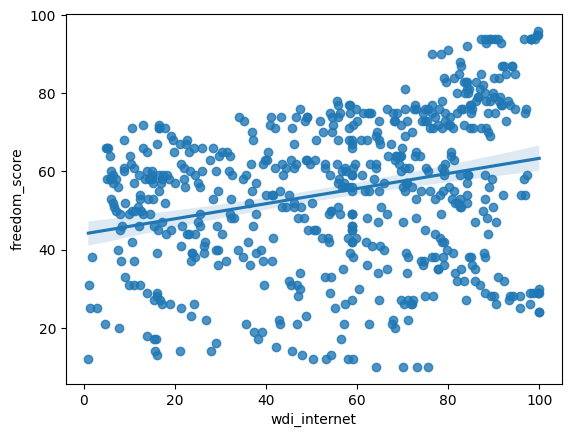

In [23]:
sns.regplot(data=data, x='wdi_internet', y='freedom_score')

<Axes: xlabel='wdi_gdpcapcon2015', ylabel='freedom_score'>

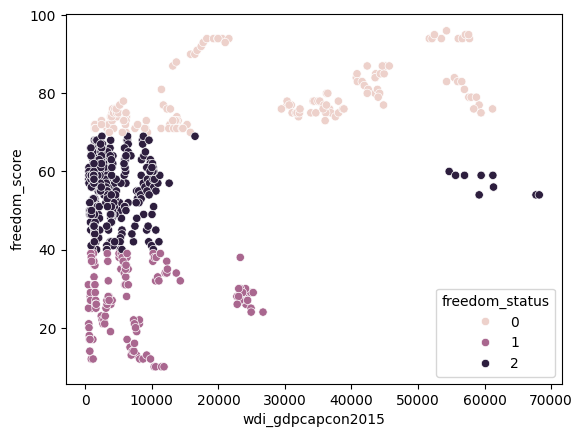

In [21]:
sns.scatterplot(data=data, x='wdi_gdpcapcon2015', y='freedom_score', hue='freedom_status')

<Axes: xlabel='wdi_gdpcapcon2015', ylabel='freedom_score'>

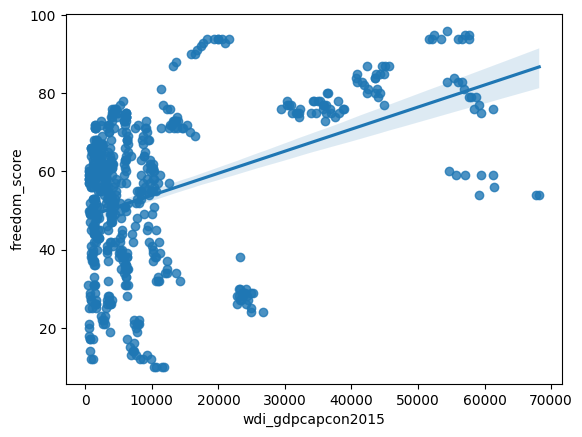

In [22]:
sns.regplot(data=data, x='wdi_gdpcapcon2015', y='freedom_score')

<Axes: xlabel='undp_hdi', ylabel='freedom_score'>

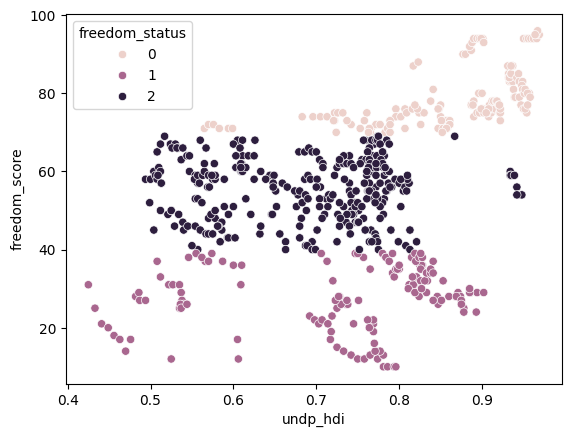

In [16]:
sns.scatterplot(data=data, x='undp_hdi', y='freedom_score', hue='freedom_status')

<Axes: xlabel='undp_hdi', ylabel='freedom_score'>

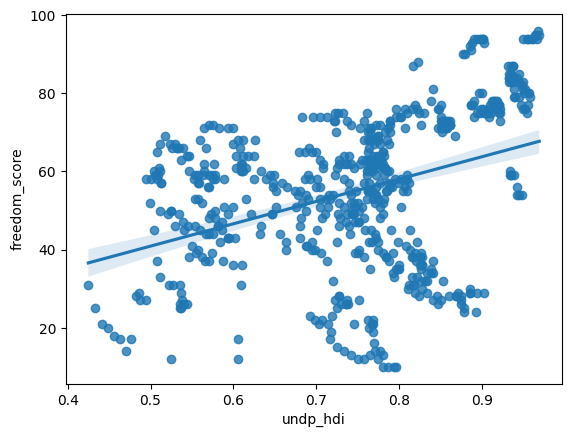

In [25]:
sns.regplot(data=data, x='undp_hdi', y='freedom_score')

<Axes: xlabel='vdem_libdem', ylabel='freedom_score'>

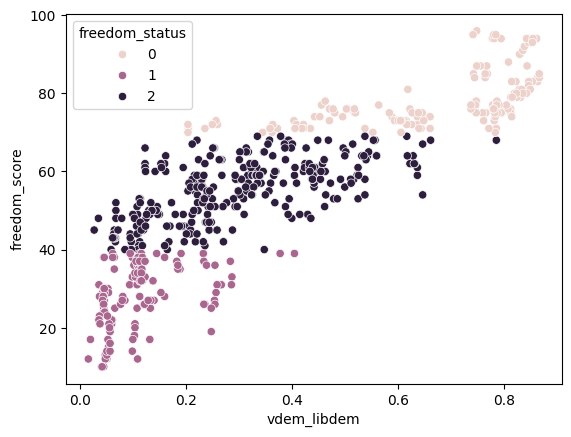

In [17]:
sns.scatterplot(data=data, x='vdem_libdem', y='freedom_score', hue='freedom_status')

<Axes: xlabel='vdem_libdem', ylabel='freedom_score'>

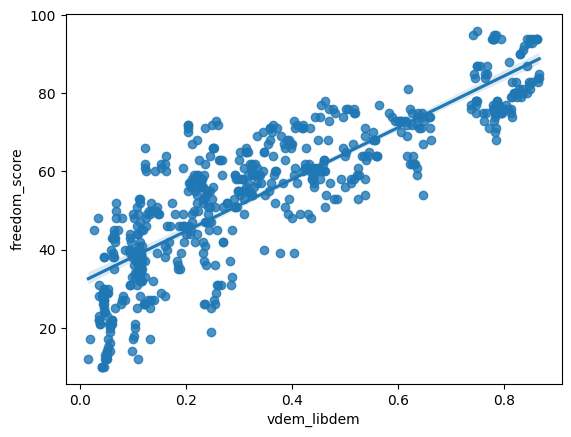

In [26]:
sns.regplot(data=data, x='vdem_libdem', y='freedom_score')

<Axes: xlabel='ti_cpi', ylabel='freedom_score'>

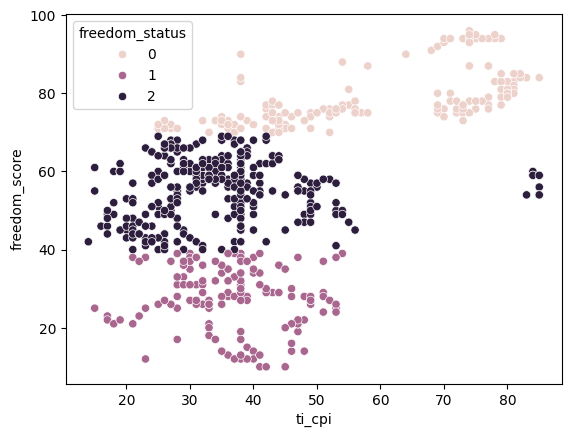

In [18]:
sns.scatterplot(data=data, x='ti_cpi', y='freedom_score', hue='freedom_status')

<Axes: xlabel='ti_cpi', ylabel='freedom_score'>

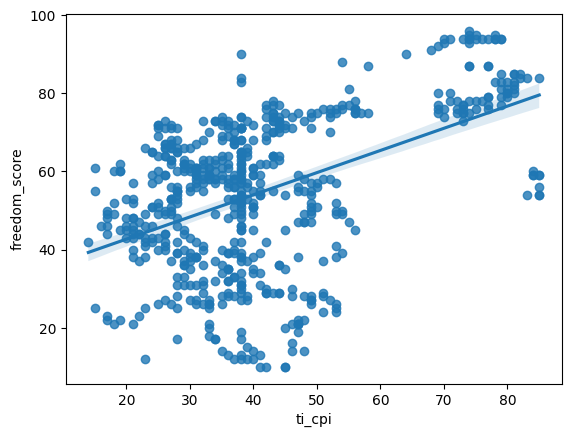

In [27]:
sns.regplot(data=data, x='ti_cpi', y='freedom_score')

# Cross Countries

<Axes: xlabel='wdi_gdpcapcon2015', ylabel='freedom_score'>

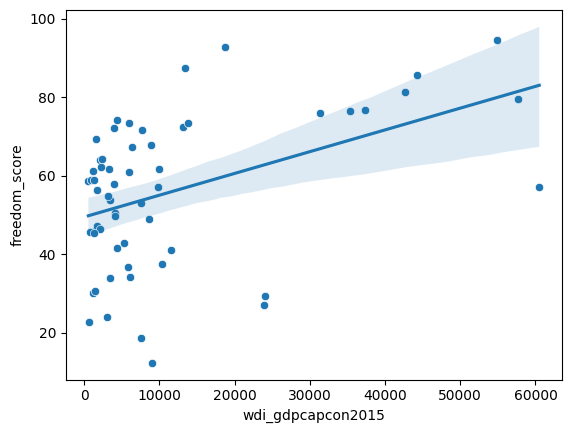

In [31]:
country_avg = data.groupby('country').mean(numeric_only=True).reset_index()

sns.scatterplot(data=country_avg, x='wdi_gdpcapcon2015', y='freedom_score')
sns.regplot(data=country_avg, x='wdi_gdpcapcon2015', y='freedom_score', scatter=False)

<Axes: xlabel='wdi_internet', ylabel='freedom_score'>

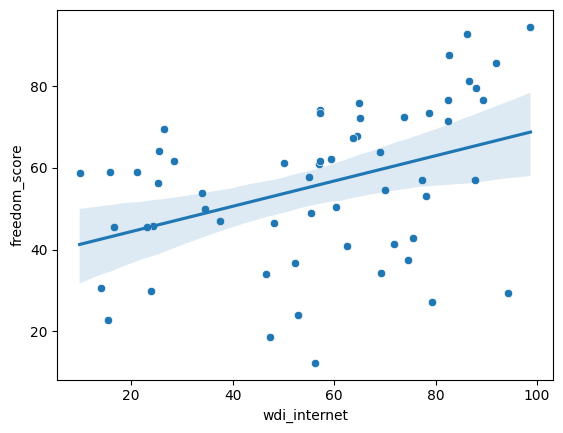

In [ ]:
sns.scatterplot(data=country_avg, x='wdi_internet', y='freedom_score')
sns.regplot(data=country_avg, x='wdi_internet', y='freedom_score', scatter=False)

<Axes: xlabel='undp_hdi', ylabel='freedom_score'>

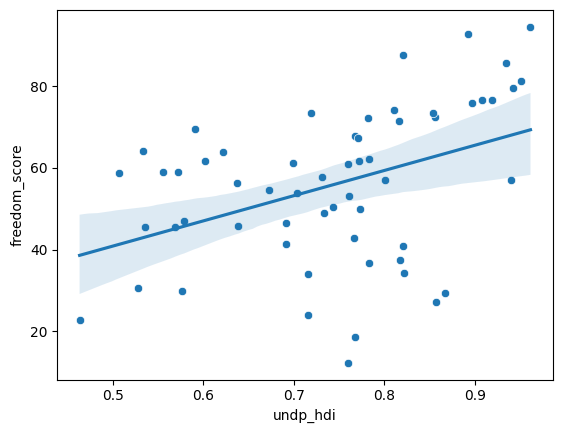

In [33]:
sns.scatterplot(data=country_avg, x='undp_hdi', y='freedom_score')
sns.regplot(data=country_avg, x='undp_hdi', y='freedom_score', scatter=False)

<Axes: xlabel='vdem_libdem', ylabel='freedom_score'>

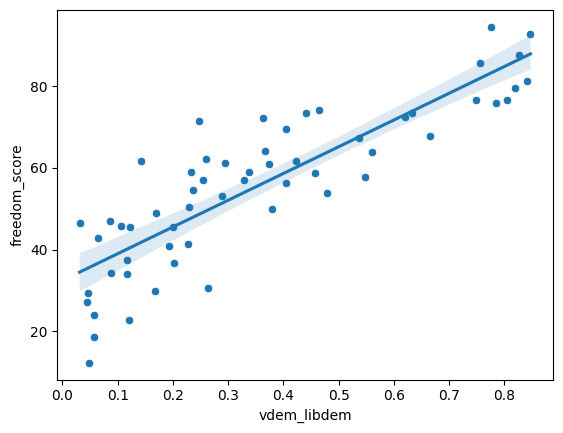

In [34]:
sns.scatterplot(data=country_avg, x='vdem_libdem', y='freedom_score')
sns.regplot(data=country_avg, x='vdem_libdem', y='freedom_score', scatter=False)

<Axes: xlabel='ti_cpi', ylabel='freedom_score'>

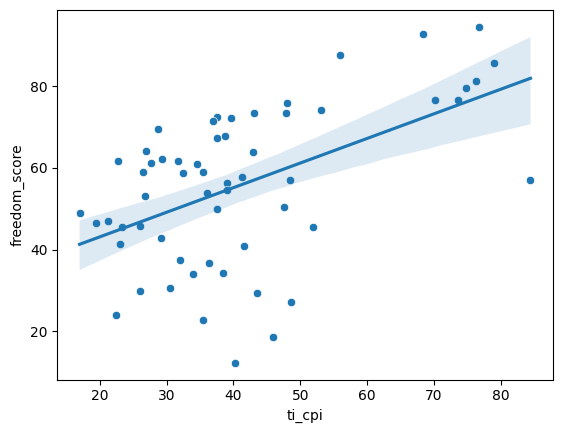

In [35]:
sns.scatterplot(data=country_avg, x='ti_cpi', y='freedom_score')
sns.regplot(data=country_avg, x='ti_cpi', y='freedom_score', scatter=False)

# Global Trend

<Axes: xlabel='year', ylabel='freedom_score'>

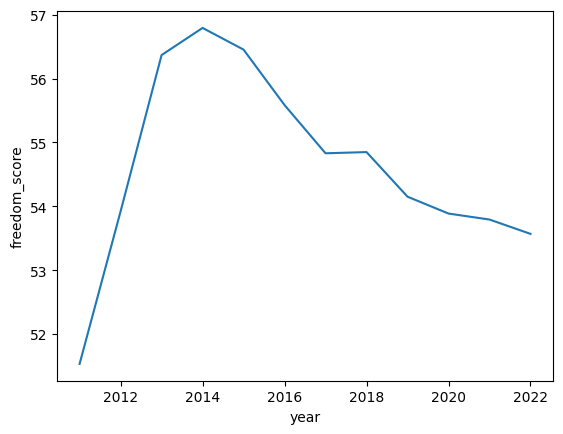

In [36]:
yearly = data.groupby('year').mean(numeric_only=True).reset_index()
sns.lineplot(data=yearly, x='year', y='freedom_score')

<Axes: xlabel='year', ylabel='wdi_internet'>

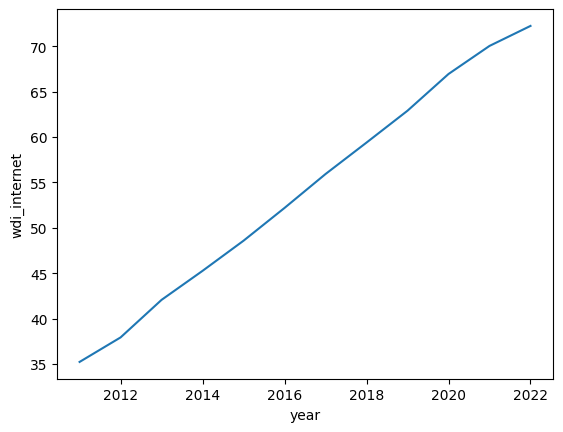

In [38]:
yearly = data.groupby('year').mean(numeric_only=True).reset_index()
sns.lineplot(data=yearly, x='year', y='wdi_internet')

<Axes: xlabel='year', ylabel='count'>

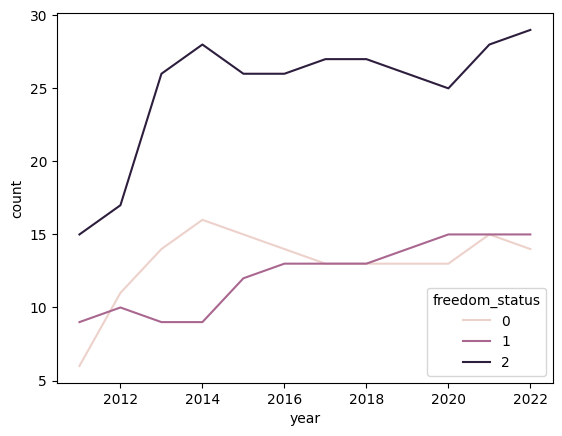

In [41]:
status_year = data.groupby(['year', 'freedom_status']).size().reset_index(name='count')
sns.lineplot(data=status_year, x='year', y='count', hue='freedom_status')

# Specific Countries

country
Azerbaijan      12
Australia       12
Bahrain         12
Brazil          12
Myanmar         12
Belarus         12
China           12
Cuba            12
Ethiopia        12
Estonia         12
Georgia         12
Germany         12
India           12
Indonesia       12
Italy           12
Kazakhstan      12
Jordan          12
Kenya           12
Malaysia        12
Mexico          12
Nigeria         12
Pakistan        12
Rwanda          12
Saudi Arabia    12
South Africa    12
Zimbabwe        12
Thailand        12
Tunisia         12
Turkey          12
Egypt           12
Argentina       11
Sri Lanka       11
Hungary         11
Kyrgyzstan      11
Libya           11
Uganda          11
Ukraine         11
Uzbekistan      11
Angola          10
Bangladesh      10
Armenia         10
Cambodia        10
Ecuador         10
France          10
Iceland         10
Japan           10
Lebanon         10
Malawi          10
Morocco         10
Canada           9
Colombia         9
Singapore        9
Zamb

<Axes: xlabel='year', ylabel='freedom_score'>

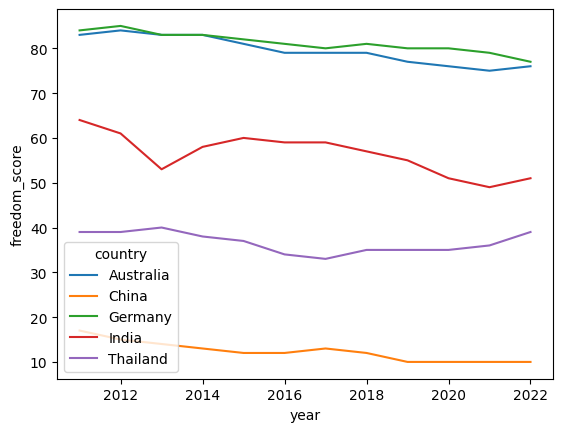

In [46]:
countries = ['Australia', 'Germany', 'Thailand', 'India', 'China']
specific_countries = data[data['country'].isin(countries)]
print(data['country'].value_counts())

sns.lineplot(data=specific_countries, x='year', y='freedom_score', hue='country')

# Modelling

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor

In [48]:
X = data[['wdi_internet', 'wdi_gdpcapcon2015', 'undp_hdi', 'vdem_libdem', 'ti_cpi']]
y = data[['freedom_score']]

scaler = StandardScaler()

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [53]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
prediction = lr.predict(X_test_scaled)

print(r2_score(y_test, prediction))
print(mean_squared_error(y_test, prediction))

0.7065796677941087
98.36096459134373


In [55]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

print(lasso.coef_)

[ 0.85451809 -0.38879058 -0.12281686 17.75322363 -1.43988625]


In [59]:
rfr = RandomForestRegressor(n_estimators=200, random_state=42)

rfr.fit(X_train, y_train)
pred = rfr.predict(X_test)

print(r2_score(y_test, pred))

importance = pd.Series(rfr.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

C:\Users\apala\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9130283873976006
vdem_libdem          0.817871
undp_hdi             0.059319
wdi_gdpcapcon2015    0.047666
ti_cpi               0.038162
wdi_internet         0.036981
dtype: float64


# Clustering

In [65]:
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

In [64]:
country_new_avg = data.groupby('country').mean(numeric_only=True)

new_scale = StandardScaler()
X_scaled = new_scale.fit_transform(country_new_avg)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [68]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [69]:
country_new_avg['cluster'] = clusters

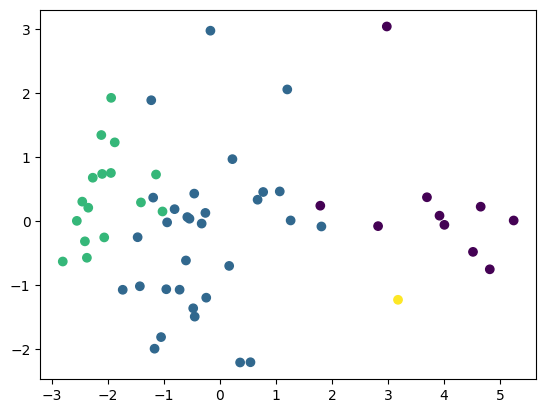

In [70]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)